In [10]:
import pandas as pd

pca = pd.read_csv(
    'pca.eigenvec',
    sep='\t',
    header=0,
    comment=None
)

pca.columns = pca.columns.str.lstrip('#')
print(pca.shape)
print(pca.columns.tolist())
pca.head()

(2504, 21)
['IID', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20']


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,HG00096_HG00096,-0.011244,-0.026611,-0.011612,0.018782,-0.004142,0.006018,0.000803,-0.018873,-0.015924,...,-0.014434,0.010272,-0.009364,-0.016536,0.002766,0.039061,-0.021697,-0.027654,0.031378,-0.001749
1,HG00097_HG00097,-0.011111,-0.026435,-0.010646,0.018776,-0.003506,0.004026,0.003191,-0.025200,-0.013347,...,0.009448,0.019598,-0.020847,-0.011809,0.007947,0.027022,-0.024687,-0.021397,0.013871,-0.022577
2,HG00099_HG00099,-0.011172,-0.026640,-0.011596,0.016946,-0.002812,0.006214,0.001511,-0.028746,-0.018301,...,0.010453,0.012046,-0.025080,-0.014757,0.016284,0.029918,-0.018650,-0.020692,0.014540,-0.014456
3,HG00100_HG00100,-0.011012,-0.026579,-0.012048,0.018777,-0.002066,-0.002123,0.002873,-0.014569,-0.007616,...,0.021684,-0.003596,-0.037978,0.012813,0.012473,0.016732,-0.023534,-0.007250,0.015758,-0.001871
4,HG00101_HG00101,-0.011041,-0.026360,-0.012020,0.018420,-0.001723,0.005794,0.004467,-0.021136,-0.012739,...,0.002908,0.006654,-0.036016,-0.017719,0.021269,0.031593,-0.026441,-0.023276,0.013248,-0.016287


In [11]:
import gzip
import numpy as np
from scipy import sparse

fname = 'pbwt_combined_chunklengths.s.out.gz'

rows = []
cols = []
vals = []
with gzip.open(fname, 'rt') as fh:
    for line in fh:
        s = line.strip()
        if not s or s.startswith('#'):
            continue
        parts = s.split()
        if len(parts) < 3:
            continue
        try:
            i = int(parts[0])
            j = int(parts[1])
            x = float(parts[2])
        except ValueError:
            continue
        rows.append(i)
        cols.append(j)
        vals.append(x)

if len(rows) == 0:
    raise ValueError("No numeric entries found in file")

rows = np.array(rows, dtype=np.int64)
cols = np.array(cols, dtype=np.int64)
vals = np.array(vals, dtype=np.float64)

# Convert 1-based indices to 0-based if both minima are > 0
if rows.min() > 0 and cols.min() > 0:
    print(f"Correcting one-based index to zero-based index")
    rows -= 1
    cols -= 1

shape = (rows.max() + 1, cols.max() + 1)
sparse_mat = sparse.coo_matrix((vals, (rows, cols)), shape=shape).tocsr()

print(f"Loaded sparse matrix shape={sparse_mat.shape}, nnz={sparse_mat.nnz}")

Correcting one-based index to zero-based index
Loaded sparse matrix shape=(2504, 2504), nnz=6267499


In [12]:
sparse_log_mat = sparse.coo_matrix((np.log10(vals+1), (rows, cols)), shape=shape).tocsr()


In [13]:

ids = pd.read_csv(
    'population_labels_ordered.txt',
    sep=' ',
    header=None,
    comment=None
)
ids.columns = ['ID','POP']
ids['IDX'] = ids.index + 1
ids.head()

,ID,POP,IDX
0,HG00096_HG00096,EUR,1
1,HG00097_HG00097,EUR,2
2,HG00099_HG00099,EUR,3
3,HG00100_HG00100,EUR,4
4,HG00101_HG00101,EUR,5


In [20]:
# Convert to 0-based indices for Python/scipy indexing
label_to_indices = (
    ids.groupby('POP')['IDX']
      .apply(lambda x: (x - 1).to_numpy())
      .to_dict()
)
unique_labels = ids['POP'].unique()

In [21]:
# Create matrices to store summaries
avg_matrix = np.zeros((len(unique_labels), len(unique_labels)))
lower_q_matrix = np.zeros((len(unique_labels), len(unique_labels)))
upper_q_matrix = np.zeros((len(unique_labels), len(unique_labels)))

for i, label_k in enumerate(unique_labels):
    for j, label_l in enumerate(unique_labels):
        indices_k = label_to_indices[label_k]
        indices_l = label_to_indices[label_l]

        # Extract submatrix
        submatrix = sparse_mat[indices_k, :][:, indices_l].toarray()

        # Store statistics
        avg_matrix[i, j] = np.mean(submatrix)
        lower_q_matrix[i, j] = np.quantile(submatrix, 0.05)
        upper_q_matrix[i, j] = np.quantile(submatrix, 0.95)

print("Average matrix:\n", avg_matrix)
print("Lower 5% quantile matrix:\n", lower_q_matrix)
print("Upper 95% quantile matrix:\n", upper_q_matrix)

Average matrix:
 [[ 933.71635071   91.73078068  430.9982386   251.66224401   64.22562187]
 [ 108.31136086 1195.01693322  168.71983549  190.38578669   34.11561045]
 [ 408.03022003  138.64971652 1127.64381402  173.86194982  120.32442511]
 [ 281.88355607  195.89580518  206.26063048  996.69281622   47.6397269 ]
 [  71.46587868   37.426047    130.45931723   51.02757711 1067.97589496]]
Lower 5% quantile matrix:
 [[452.46496  45.42362 136.17    122.2365   10.99163]
 [ 55.7518  614.78365  70.52041 105.9257   13.2175 ]
 [142.2078   50.59722 302.8909   87.48446  17.92733]
 [151.23039  98.18645 104.04705 495.1278   17.1104 ]
 [ 15.73262  14.02983  21.57712  19.09834 453.0578 ]]
Upper 95% quantile matrix:
 [[1717.4514    150.81954   794.7504    423.27913   218.46488 ]
 [ 176.36856  2298.65955   320.49839   314.206425   64.344585]
 [ 732.463     272.285305 3401.29556   292.45959   337.12934 ]
 [ 460.75157   338.858225  341.65374  1653.6566    102.14612 ]
 [ 223.87241    69.977815  352.06953   101.9

In [22]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# hierarchical clustering on avg_matrix rows
dist_vec = pdist(avg_matrix, metric='euclidean')
Z = linkage(dist_vec, method='average')
order = leaves_list(Z)

# reorder matrix and labels
avg_matrix_sorted = avg_matrix[np.ix_(order, order)]
unique_labels_sorted = unique_labels[order]
lower_q_sorted = lower_q_matrix[order,order]
upper_q_sorted = upper_q_matrix[order,order]
print("order:", order)
print("unique_labels_sorted:", unique_labels_sorted)
print("avg_matrix_sorted:\n", avg_matrix_sorted)

order: [4 1 3 0 2]
unique_labels_sorted: ['AFR' 'EAS' 'SAS' 'EUR' 'AMR']
avg_matrix_sorted:
 [[1067.97589496   37.426047     51.02757711   71.46587868  130.45931723]
 [  34.11561045 1195.01693322  190.38578669  108.31136086  168.71983549]
 [  47.6397269   195.89580518  996.69281622  281.88355607  206.26063048]
 [  64.22562187   91.73078068  251.66224401  933.71635071  430.9982386 ]
 [ 120.32442511  138.64971652  173.86194982  408.03022003 1127.64381402]]


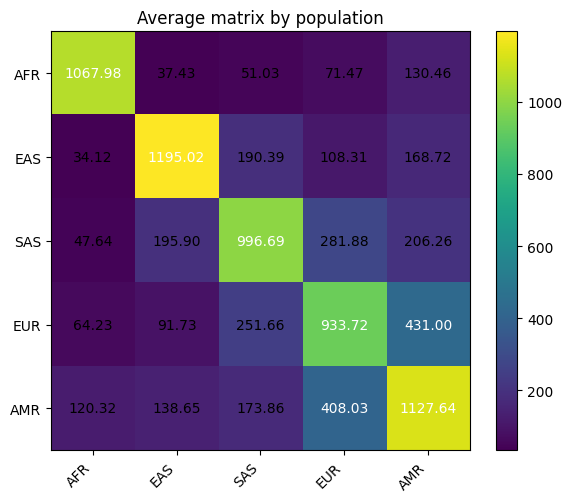

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(avg_matrix_sorted, cmap='viridis', aspect='equal')
plt.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(unique_labels_sorted)))
ax.set_yticks(np.arange(len(unique_labels_sorted)))
ax.set_xticklabels(unique_labels_sorted)
ax.set_yticklabels(unique_labels_sorted)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

mean_val = avg_matrix_sorted.mean()
for i in range(avg_matrix_sorted.shape[0]):
    for j in range(avg_matrix_sorted.shape[1]):
        v = avg_matrix_sorted[i, j]
        color = 'white' if v > mean_val else 'black'
        ax.text(j, i, f"{v:.2f}", ha='center', va='center', color=color)

ax.set_title("Average matrix by population")
plt.tight_layout()
plt.show()

In [25]:
from scipy.sparse import linalg

# Compute sparse SVD
target_mat = sparse_log_mat
target_sym = (target_mat + target_mat.T) / 2
U, s, Vt = linalg.svds(target_sym, k=int(np.ceil(np.sqrt(min(target_sym.shape)))))

s = s[::-1]
U = U[:, ::-1]
Vt = Vt[::-1, :]

print(f"U shape: {U.shape}")
print(f"Singular values shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")
print(f"Top 10 singular values: {s[:10]}")

U shape: (2504, 51)
Singular values shape: (51,)
Vt shape: (51, 2504)
Top 10 singular values: [5464.17371571 1038.09676518  563.13365554  293.42769585  152.66379789
   82.49953069   71.11798132   62.46633274   62.09300533   51.92691349]


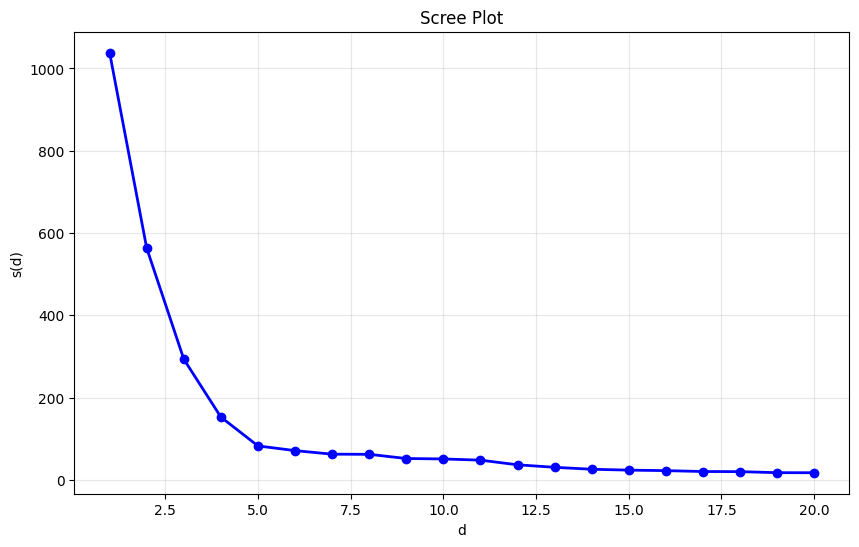

In [26]:

# Create scree plot for first 20 singular values
d = np.arange(1, 21)
s_d = s[d]  # Get the last 20 singular values in reverse order

plt.figure(figsize=(10, 6))
plt.plot(d, s_d, 'bo-', linewidth=2, markersize=6)
plt.xlabel('d')
plt.ylabel('s(d)')
plt.title('Scree Plot')
plt.grid(True, alpha=0.3)
plt.show()

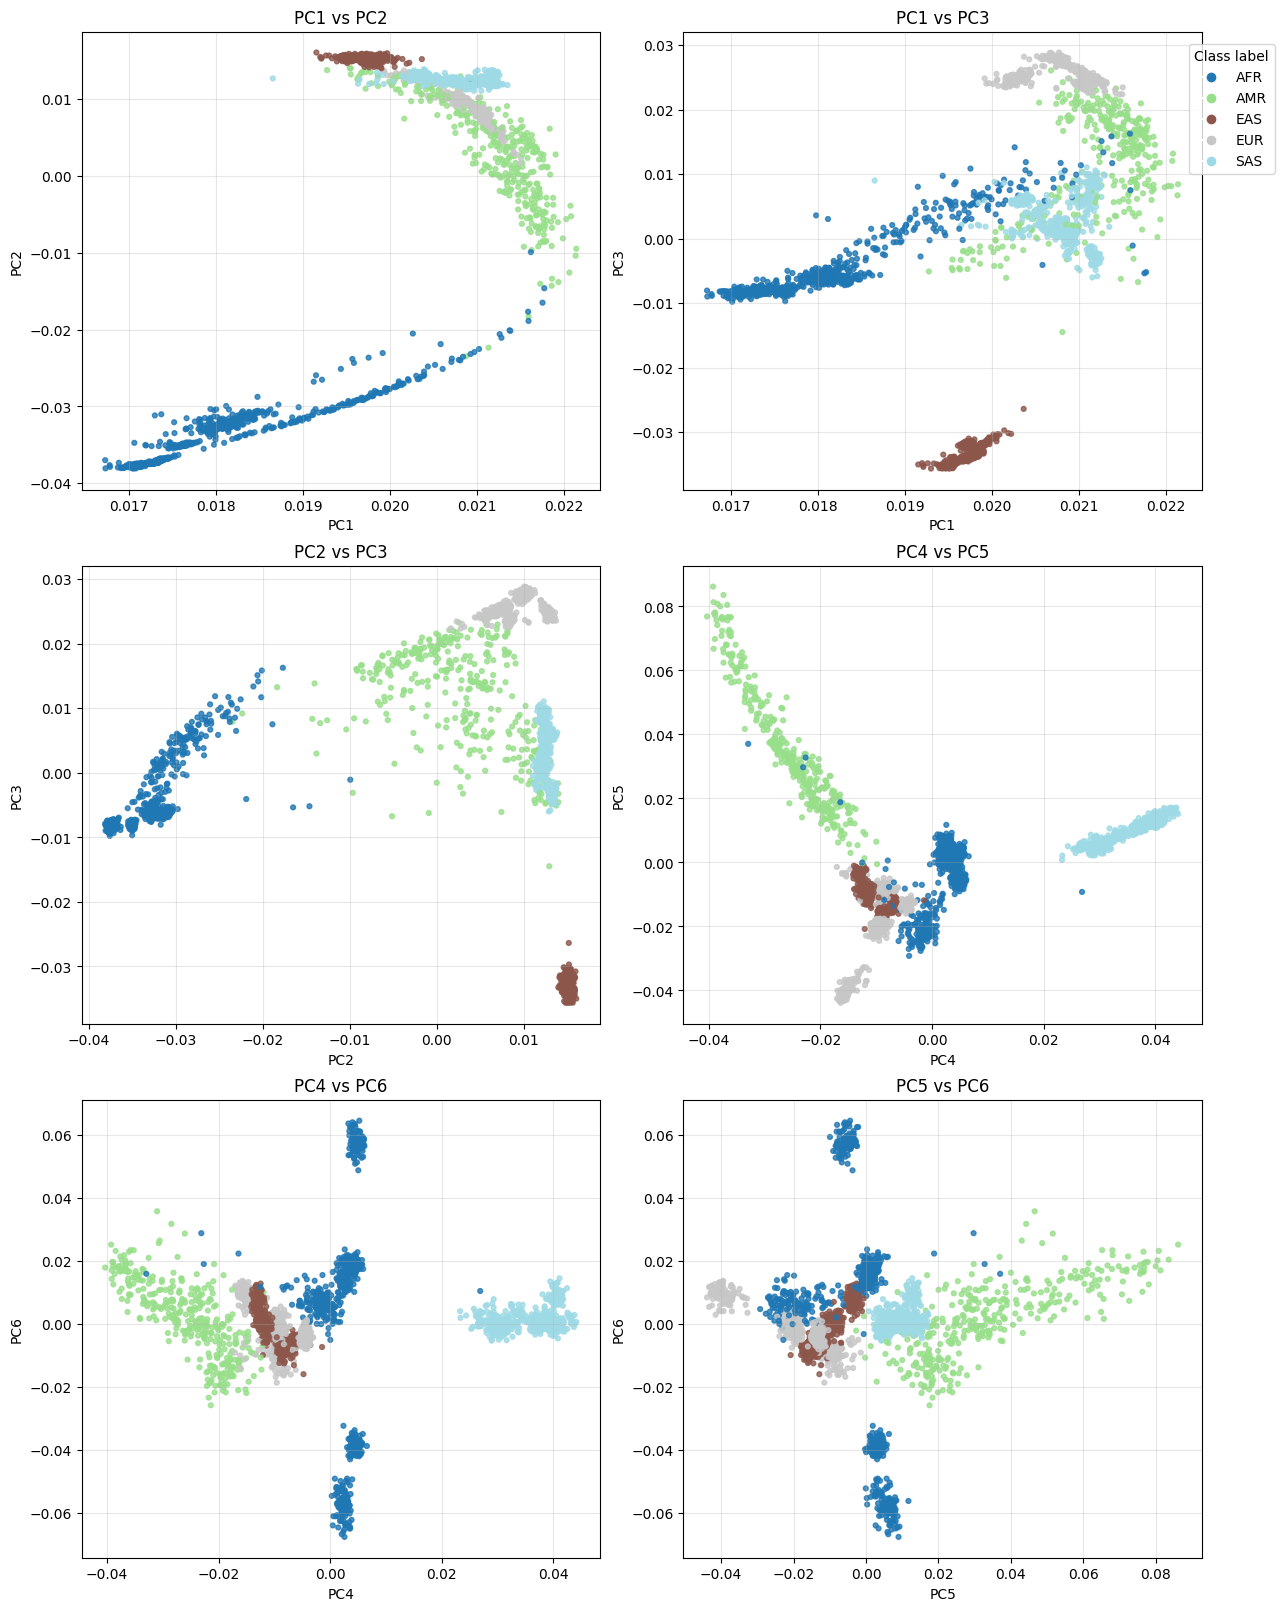

In [29]:
from matplotlib.colors import ListedColormap

# plot 6 PC pairs in a 3x2 grid, coloring points by class label
label_arr = np.array(ids['POP'])
unique_labels = np.unique(label_arr)
label_to_index = {lab: idx for idx, lab in enumerate(unique_labels)}
label_indices = np.array([label_to_index[lab] for lab in label_arr])

pc_pairs = [(1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (5, 6)]

cmap = plt.get_cmap('tab20', len(unique_labels))

fig, axes = plt.subplots(3, 2, figsize=(12, 16), constrained_layout=True)
axes = axes.ravel()

for ax, (pi, pj) in zip(axes, pc_pairs):
    x = Vt[pi - 1,:]
    y = Vt[pj - 1,:]
    scatter = ax.scatter(x, y, c=label_indices, cmap=cmap, s=12, alpha=0.8)
    ax.set_xlabel(f'PC{pi}')
    ax.set_ylabel(f'PC{pj}')
    ax.set_title(f'PC{pi} vs PC{pj}')
    ax.grid(True, alpha=0.3)

# create a legend for class labels
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(idx), markersize=8)
    for idx in range(len(unique_labels))
]
fig.legend(handles, unique_labels, title='Class label', loc='upper left', bbox_to_anchor=(0.98, 0.98))

plt.show()

In [31]:
import plotly.express as px

pcs = [1,2,3,4]

fig = px.scatter_matrix(
    pd.DataFrame({
        f"PC{i}": Vt[i-1, :]
        for i in pcs
    }).assign(label=label_arr),
    dimensions=[f"PC{i}" for i in pcs],
    color="label"
)
fig.update_layout(
        width=1000,
        height=1000)
fig.show()


In [32]:
import pandas as pd

def plot_pcs_3d(Vt, labels, pcx, pcy, pcz,
                width=1000, height=800):
    df = pd.DataFrame({
        f"PC{pcx}": Vt[pcx - 1, :],
        f"PC{pcy}": Vt[pcy - 1, :],
        f"PC{pcz}": Vt[pcz - 1, :],
        "label": labels
    })

    fig = px.scatter_3d(
        df,
        x=f"PC{pcx}",
        y=f"PC{pcy}",
        z=f"PC{pcz}",
        color="label",
        opacity=0.8
    )

    fig.update_traces(marker=dict(size=3))

    fig.update_layout(
        width=width,
        height=height,
        scene=dict(aspectmode="cube")
    )

    fig.update_layout(
        legend=dict(
            itemsizing="constant"
        )
    )


    fig.show()

    return fig

In [33]:
fig = plot_pcs_3d(Vt, label_arr.astype(str), 2, 3, 4)

In [34]:
fig = plot_pcs_3d(Vt, label_arr.astype(str), 3,4,5)

In [43]:
import umap
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler


X = (np.sqrt(s[:6])[:, None] * Vt[:6, :]).T
#X = ((s[:6])[:, None] * Vt[:6, :]).T
X_scaled = StandardScaler().fit_transform(X)

embedding = umap.UMAP(
    n_components=3,
    n_neighbors=500,
    min_dist=1,
    random_state=42
).fit_transform(X_scaled)

df = pd.DataFrame({
    "UMAP1": embedding[:, 0],
    "UMAP2": embedding[:, 1],
    "UMAP3": embedding[:, 2],
    "label": label_arr.astype(str)
})

fig = px.scatter_3d(
    df,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="label",
    opacity=0.8
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(
    legend=dict(
        itemsizing="constant"
    )
)
fig.update_layout(
    height=900,
    width=1000,
    scene=dict(aspectmode="cube")
)

fig.show()

/Users/madjl/uv/default_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



/Users/madjl/uv/default_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



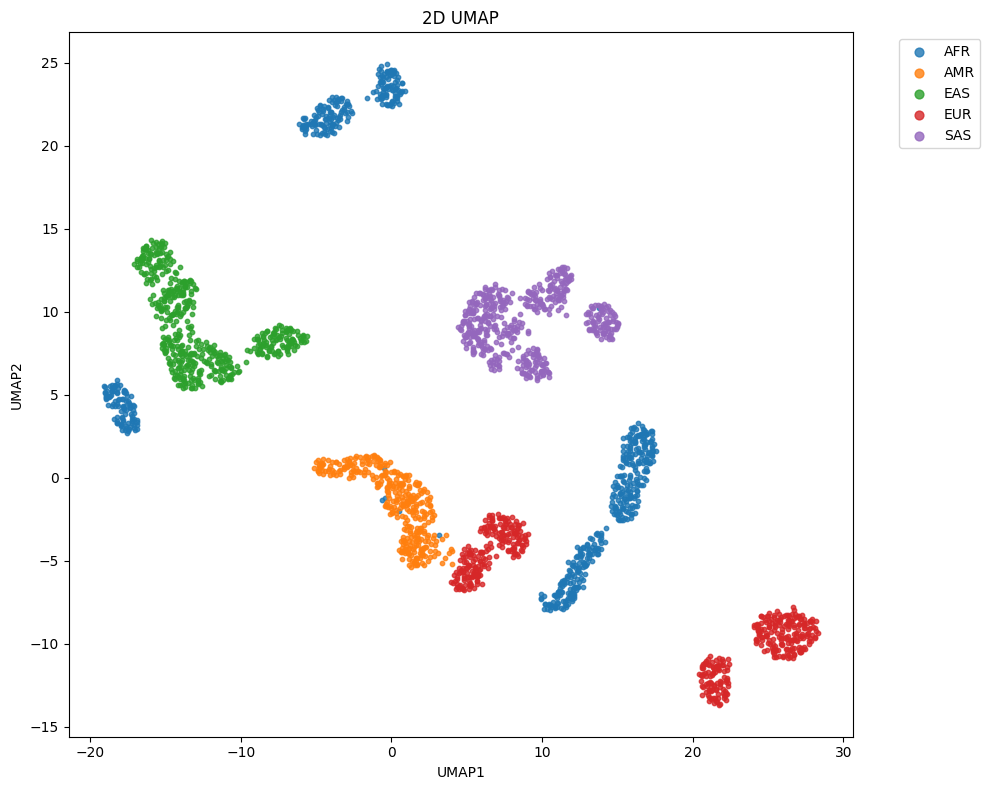

In [44]:
import umap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = (np.sqrt(s[:6])[:, None] * Vt[:6, :]).T
#X = ((s[:6])[:, None] * Vt[:6, :]).T
X_scaled = StandardScaler().fit_transform(X)

embedding = umap.UMAP(
    n_components=2,
    n_neighbors=500,
    min_dist=1,
    random_state=42
).fit_transform(X_scaled)

df = pd.DataFrame({
    "UMAP1": embedding[:, 0],
    "UMAP2": embedding[:, 1],
    "label": label_arr.astype(str)
})

fig, ax = plt.subplots(figsize=(10, 8))

for label, group in df.groupby("label"):
    ax.scatter(
        group["UMAP1"],
        group["UMAP2"],
        s=10,
        alpha=0.8,
        label=label
    )

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("2D UMAP")
ax.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()